# Enron Email Analytics & NLP

Analyzed 500,000+ real-world corporate emails from the Enron dataset using Python, NLP, and data visualization.

## Goals
- Parse raw email messages
- Extract sender, recipient, subject, and date metadata
- Analyze communication patterns
- Identify frequent terms and organizational email trends

In [1]:
import pandas as pd
import numpy as np
import zipfile
import re
from email import message_from_string
from collections import Counter

import matplotlib.pyplot as plt

In [2]:
with zipfile.ZipFile("archive.zip") as z:
    with z.open("emails.csv") as f:
        emails = pd.read_csv(f)

emails.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [3]:
print("Dataset shape:", emails.shape)
emails.info()

Dataset shape: (517401, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517401 entries, 0 to 517400
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   file     517401 non-null  object
 1   message  517401 non-null  object
dtypes: object(2)
memory usage: 7.9+ MB


In [4]:
emails["message"].iloc[0][:1000]

"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>\nDate: Mon, 14 May 2001 16:39:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: tim.belden@enron.com\nSubject: \nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: Tim Belden <Tim Belden/Enron@EnronXGate>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pallen (Non-Privileged).pst\n\nHere is our forecast\n\n "

In [5]:
def parse_email(raw_message):
    msg = message_from_string(raw_message)
    
    return {
        "date": msg.get("Date"),
        "from": msg.get("From"),
        "to": msg.get("To"),
        "subject": msg.get("Subject"),
        "body": msg.get_payload()
    }

parsed = emails["message"].apply(parse_email)
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df.head()

,date,from,to,subject,body
0,"Mon, 14 May 2001 16:39:00 -0700 (PDT)",phillip.allen@enron.com,tim.belden@enron.com,,Here is our forecast\n\n
1,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,Re:,Traveling to have a business meeting takes the...
2,"Wed, 18 Oct 2000 03:00:00 -0700 (PDT)",phillip.allen@enron.com,leah.arsdall@enron.com,Re: test,test successful. way to go!!!
3,"Mon, 23 Oct 2000 06:13:00 -0700 (PDT)",phillip.allen@enron.com,randall.gay@enron.com,,"Randy,\n\n Can you send me a schedule of the s..."
4,"Thu, 31 Aug 2000 05:07:00 -0700 (PDT)",phillip.allen@enron.com,greg.piper@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.


In [6]:
df = parsed_df.copy()

df["body"] = df["body"].astype(str)
df["subject"] = df["subject"].fillna("")
df["from"] = df["from"].fillna("")
df["to"] = df["to"].fillna("")

df["body_length"] = df["body"].apply(len)
df["word_count"] = df["body"].apply(lambda x: len(x.split()))

df.head()

,date,from,to,subject,body,body_length,word_count
0,"Mon, 14 May 2001 16:39:00 -0700 (PDT)",phillip.allen@enron.com,tim.belden@enron.com,,Here is our forecast\n\n,23,4
1,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,Re:,Traveling to have a business meeting takes the...,786,139
2,"Wed, 18 Oct 2000 03:00:00 -0700 (PDT)",phillip.allen@enron.com,leah.arsdall@enron.com,Re: test,test successful. way to go!!!,30,5
3,"Mon, 23 Oct 2000 06:13:00 -0700 (PDT)",phillip.allen@enron.com,randall.gay@enron.com,,"Randy,\n\n Can you send me a schedule of the s...",187,34
4,"Thu, 31 Aug 2000 05:07:00 -0700 (PDT)",phillip.allen@enron.com,greg.piper@enron.com,Re: Hello,Let's shoot for Tuesday at 11:45.,35,6


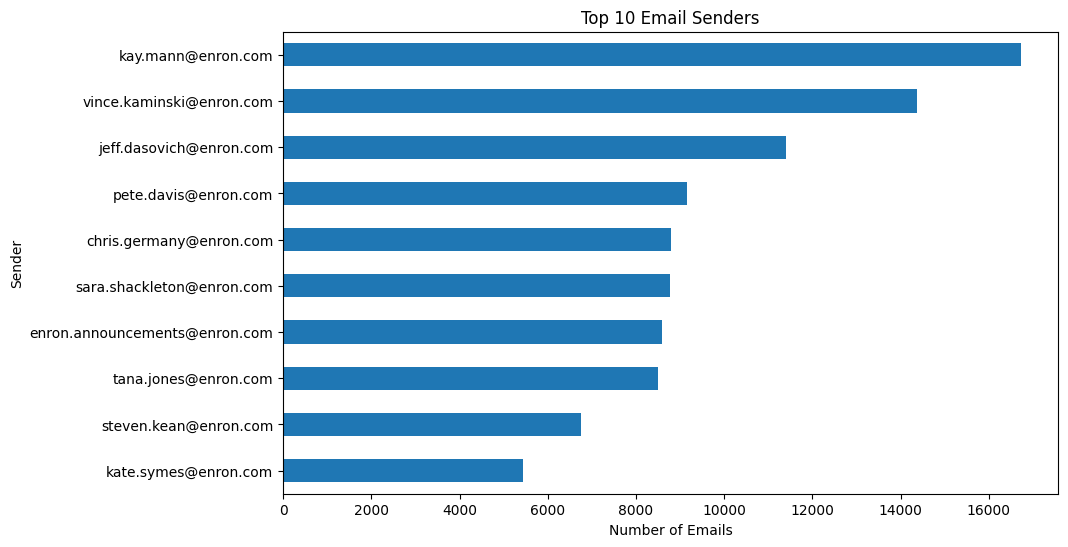

In [7]:
top_senders = df["from"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_senders.sort_values().plot(kind="barh")
plt.title("Top 10 Email Senders")
plt.xlabel("Number of Emails")
plt.ylabel("Sender")
plt.show()

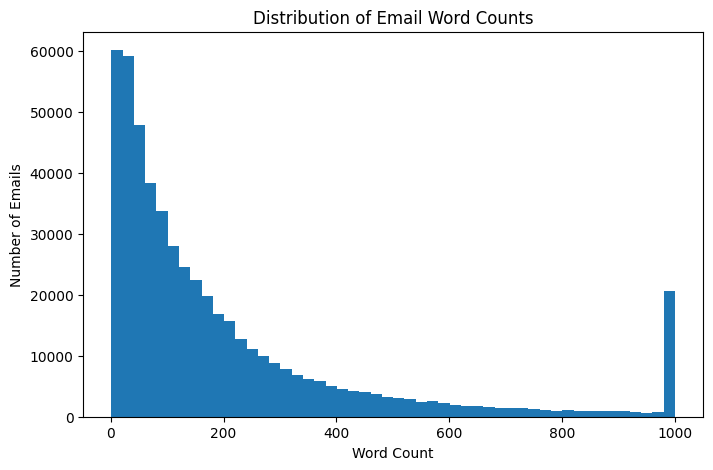

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["word_count"].clip(upper=1000), bins=50)
plt.title("Distribution of Email Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of Emails")
plt.show()

In [9]:
stop_words = {
    "the", "and", "for", "you", "that", "this", "with", "from", "have",
    "will", "are", "not", "your", "all", "our", "can", "has", "was",
    "but", "they", "his", "her", "she", "him", "would", "there", "their",
    "about", "subject", "http", "www", "com"
}

sample_text = " ".join(df["body"].sample(10000, random_state=42).astype(str))
words = re.findall(r"\b[a-zA-Z]{3,}\b", sample_text.lower())

filtered_words = [word for word in words if word not in stop_words]

word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

common_words

,word,count
0,enron,35232
1,ect,23213
2,hou,11424
3,please,7453
4,power,6833
5,energy,6778
6,any,6160
7,corp,5589
8,new,5515
9,said,5343


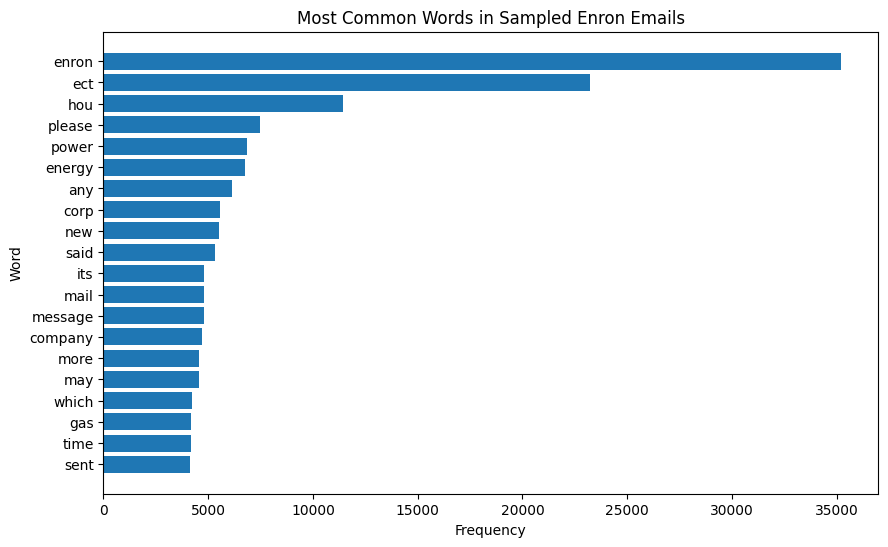

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(common_words["word"][::-1], common_words["count"][::-1])
plt.title("Most Common Words in Sampled Enron Emails")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [11]:
keywords = ["meeting", "deal", "energy", "contract", "price", "schedule", "risk"]

for keyword in keywords:
    df[f"subject_contains_{keyword}"] = df["subject"].str.lower().str.contains(keyword, na=False)

keyword_counts = {
    keyword: df[f"subject_contains_{keyword}"].sum()
    for keyword in keywords
}

keyword_df = pd.DataFrame(
    keyword_counts.items(),
    columns=["keyword", "count"]
).sort_values("count", ascending=False)

keyword_df

,keyword,count
0,meeting,17318
2,energy,10953
1,deal,8757
5,schedule,6713
3,contract,6007
4,price,4544
6,risk,3250


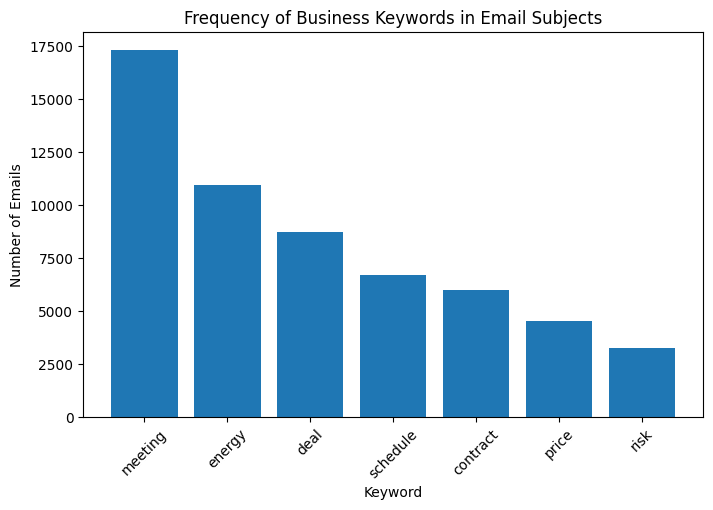

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(keyword_df["keyword"], keyword_df["count"])
plt.title("Frequency of Business Keywords in Email Subjects")
plt.xlabel("Keyword")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45)
plt.show()

## Results

This project analyzed 500,000+ corporate emails from the Enron dataset.

Key findings:
- Parsed raw email messages into structured metadata including sender, recipient, subject, date, and body text.
- Identified the most active senders in the dataset.
- Analyzed email length distributions to understand communication patterns.
- Extracted frequent terms and business-related keywords from email content and subject lines.

## Tools Used
Python, Pandas, NumPy, Matplotlib, Regex, NLP preprocessing